# PatchCore — Results Analysis
Notebook for visualizing results produced by `evaluate()` and `evaluate_from_db()`.

**Supported inputs:**
- CSV from `evaluate()` — columns: `name, mu, sigma, threshold, free_scores, fp_count, obstr_score, is_tp`
- CSV from `evaluate_from_db()` — columns: `reference_id, test_id, test_type, venue_type, file_path, score, threshold, is_anomaly`
- SQLite DB (optional) — tables `experiments` + `results`

Set the paths in the configuration cell, then run everything with **Run All**.

In [29]:
# ── Dependencies ────────────────────────────────────────────────────────────────
# pip install pandas matplotlib seaborn scikit-learn opencv-python pillow

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_curve, roc_auc_score, precision_recall_curve

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [30]:
# ── Configuration ────────────────────────────────────────────────────────────

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in dir() else Path.cwd()
SOURCE = 'evaluate_db'  # or 'evaluate' for simple CSV
CSV_PATH = 'results_p3.csv'
DB_PATH = None  # e.g., 'occlusion.db'

def resolve_input_path(raw_path: str) -> Path:
    """Resolve a file path by checking multiple roots."""
    candidate = Path(raw_path)
    if candidate.is_absolute():
        return candidate
    search_roots = [NOTEBOOK_DIR, NOTEBOOK_DIR.parent]
    for root in search_roots:
        resolved = (root / candidate).resolve()
        if resolved.exists():
            return resolved
    # If not found, return the default location
    return (NOTEBOOK_DIR.parent / candidate).resolve()

CSV_FILE = resolve_input_path(CSV_PATH)
print(f'CSV file resolved to: {CSV_FILE}')
print(f'File exists: {CSV_FILE.exists()}')

CSV file resolved to: C:\Users\andrea\OneDrive - University of Pisa\Università\Unipi\tesi\src\results_p3.csv
File exists: True


---
## 1. Data Loading

In [31]:
# ── Load CSV and normalize to common format ──────────────────────────────────

def load_evaluate_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate() — one row per background image."""
    df = pd.read_csv(path)
    # free_scores is stored as JSON string '[0.123, ...]'
    df['free_scores'] = df['free_scores'].apply(json.loads)
    # Expand into separate rows (one for each free test)
    free_rows = []
    for _, row in df.iterrows():
        for s in row['free_scores']:
            free_rows.append({
                'name': row['name'],
                'score': s,
                'threshold': row['threshold'],
                'test_type': 'normal',
                'is_anomaly': int(s > row['threshold']),
                'venue_type': 'n/a',
            })
        if pd.notna(row.get('obstr_score')):
            free_rows.append({
                'name': row['name'],
                'score': row['obstr_score'],
                'threshold': row['threshold'],
                'test_type': 'obstructed',
                'is_anomaly': int(row['is_tp']) if pd.notna(row.get('is_tp')) else None,
                'venue_type': 'n/a',
            })
    return pd.DataFrame(free_rows)


def load_evaluate_db_csv(path: str) -> pd.DataFrame:
    """CSV from evaluate_from_db() — one row per (reference, test) pair."""
    df = pd.read_csv(path)
    df['is_anomaly'] = df['is_anomaly'].astype(int)
    return df


if SOURCE == 'evaluate':
    df = load_evaluate_csv(str(CSV_FILE))
else:
    df = load_evaluate_db_csv(str(CSV_FILE))

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Rows loaded: 2970
Columns: ['reference_id', 'test_id', 'test_type', 'venue_type', 'file_path', 'score', 'normalized_score', 'threshold', 'is_anomaly']


,reference_id,test_id,test_type,venue_type,file_path,score,normalized_score,threshold,is_anomaly
0,non_ostruite/corridoi/corridoio_001.jpeg,non_ostruite/corridoi/corridoio_001.jpeg,normal,corridoio,non_ostruite/corridoi/corridoio_001.jpeg,2.523331,-1.157781,2.637938,0
1,non_ostruite/corridoi/corridoio_001.jpeg,ostruzioni_reali/images/corridoio_001_ostruita...,obstructed,corridoio,ostruzioni_reali/images/corridoio_001_ostruita...,4.858982,83.576849,2.637938,1
2,non_ostruite/corridoi/corridoio_002.jpg,non_ostruite/corridoi/corridoio_002.jpg,normal,corridoio,non_ostruite/corridoi/corridoio_002.jpg,2.208850,-1.569484,2.361172,0
3,non_ostruite/corridoi/corridoio_002.jpg,ostruzioni_reali/images/corridoio_002_ostruita...,obstructed,corridoio,ostruzioni_reali/images/corridoio_002_ostruita...,4.705634,73.331319,2.361172,1
4,non_ostruite/corridoi/corridoio_003.jpg,non_ostruite/corridoi/corridoio_003.jpg,normal,corridoio,non_ostruite/corridoi/corridoio_003.jpg,2.523704,-0.877216,2.583250,0


In [32]:
# ── Split data by test_type ─────────────────────────────────────────────────

normal_df = df[df['test_type'] == 'normal']
obstructed_df = df[df['test_type'] == 'obstructed']
shadow_df = df[df['test_type'] == 'shadow'] if 'shadow' in df['test_type'].unique() else pd.DataFrame()

print(f'Normal: {len(normal_df)} rows')
print(f'Obstructed: {len(obstructed_df)} rows')
print(f'Shadow: {len(shadow_df)} rows')
print(f'Total: {len(df)} rows')

Normal: 990 rows
Obstructed: 990 rows
Shadow: 0 rows
Total: 2970 rows


---
## 2. Anomaly Score Distribution

C:\Users\andrea\AppData\Local\Temp\ipykernel_11380\1519520903.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=labels)


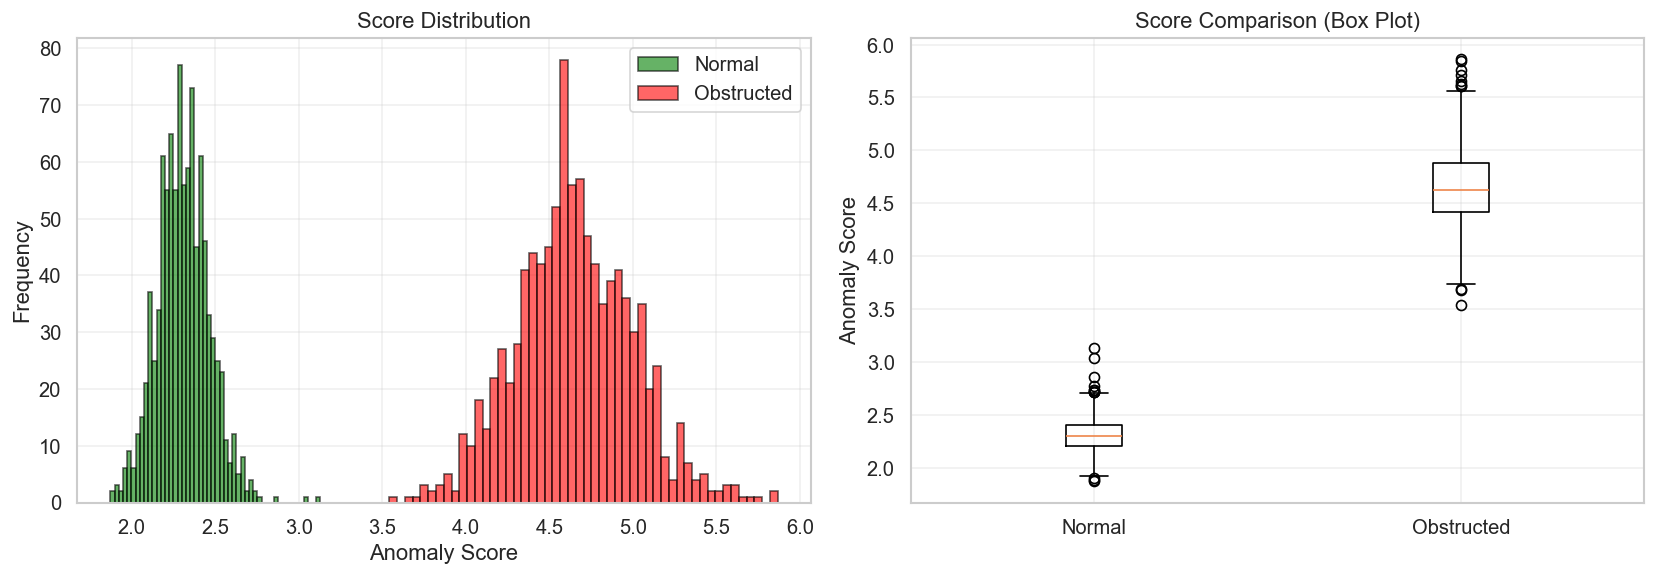

=== Score Statistics ===
Normal:     mean=2.3093, std=0.1556
Obstructed: mean=4.6476, std=0.3478


In [33]:
# ── Score distribution ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(normal_df['score'], bins=50, alpha=0.6, label='Normal', color='green', edgecolor='black')
axes[0].hist(obstructed_df['score'], bins=50, alpha=0.6, label='Obstructed', color='red', edgecolor='black')
if len(shadow_df) > 0:
    axes[0].hist(shadow_df['score'], bins=50, alpha=0.6, label='Shadow', color='orange', edgecolor='black')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [normal_df['score'], obstructed_df['score']]
labels = ['Normal', 'Obstructed']
if len(shadow_df) > 0:
    data_to_plot.append(shadow_df['score'])
    labels.append('Shadow')
axes[1].boxplot(data_to_plot, labels=labels)
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Score Comparison (Box Plot)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print('=== Score Statistics ===')
print(f'Normal:     mean={normal_df["score"].mean():.4f}, std={normal_df["score"].std():.4f}')
print(f'Obstructed: mean={obstructed_df["score"].mean():.4f}, std={obstructed_df["score"].std():.4f}')
if len(shadow_df) > 0:
    print(f'Shadow:     mean={shadow_df["score"].mean():.4f}, std={shadow_df["score"].std():.4f}')

---
## 3. ROC Curve and Precision-Recall

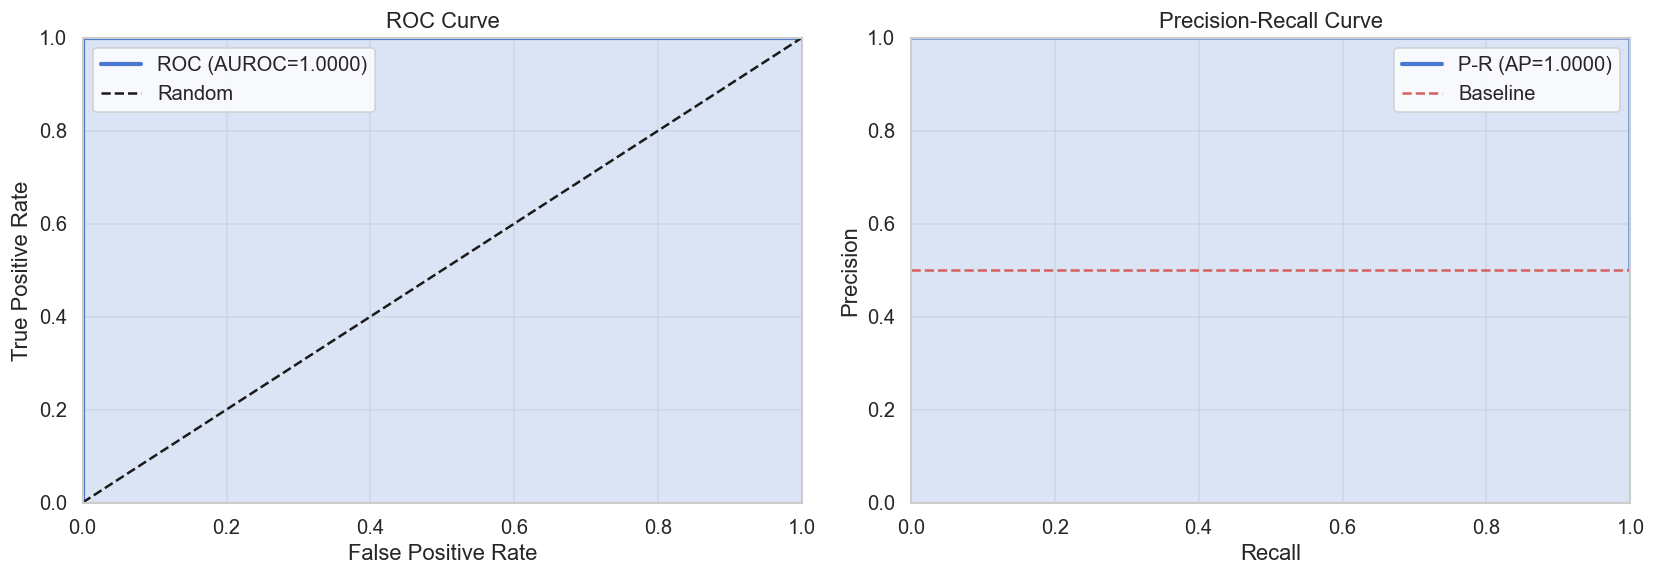

AUROC: 1.0000
AP: 1.0000


In [34]:
# ── ROC Curve and Precision-Recall ──────────────────────────────────────────

# Combine normal and obstructed, label as 0/1
all_scores = pd.concat([normal_df['score'], obstructed_df['score']], ignore_index=True)
all_labels = pd.concat([
    pd.Series([0] * len(normal_df)),
    pd.Series([1] * len(obstructed_df))
], ignore_index=True)

# ROC
fpr, tpr, thresholds_roc = roc_curve(all_labels, all_scores)
auroc = roc_auc_score(all_labels, all_scores)

# Precision-Recall
prec, rec, thresholds_pr = precision_recall_curve(all_labels, all_scores)
ap = average_precision_score(all_labels, all_scores)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2.5, label=f'ROC (AUROC={auroc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.2)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Precision-Recall
axes[1].plot(rec, prec, lw=2.5, label=f'P-R (AP={ap:.4f})')
axes[1].axhline(y=all_labels.sum() / len(all_labels), color='r', linestyle='--', lw=1.5, label='Baseline')
axes[1].fill_between(rec, prec, alpha=0.2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f'AUROC: {auroc:.4f}')
print(f'AP: {ap:.4f}')

---
## 4. FPR / TPR per venue_type

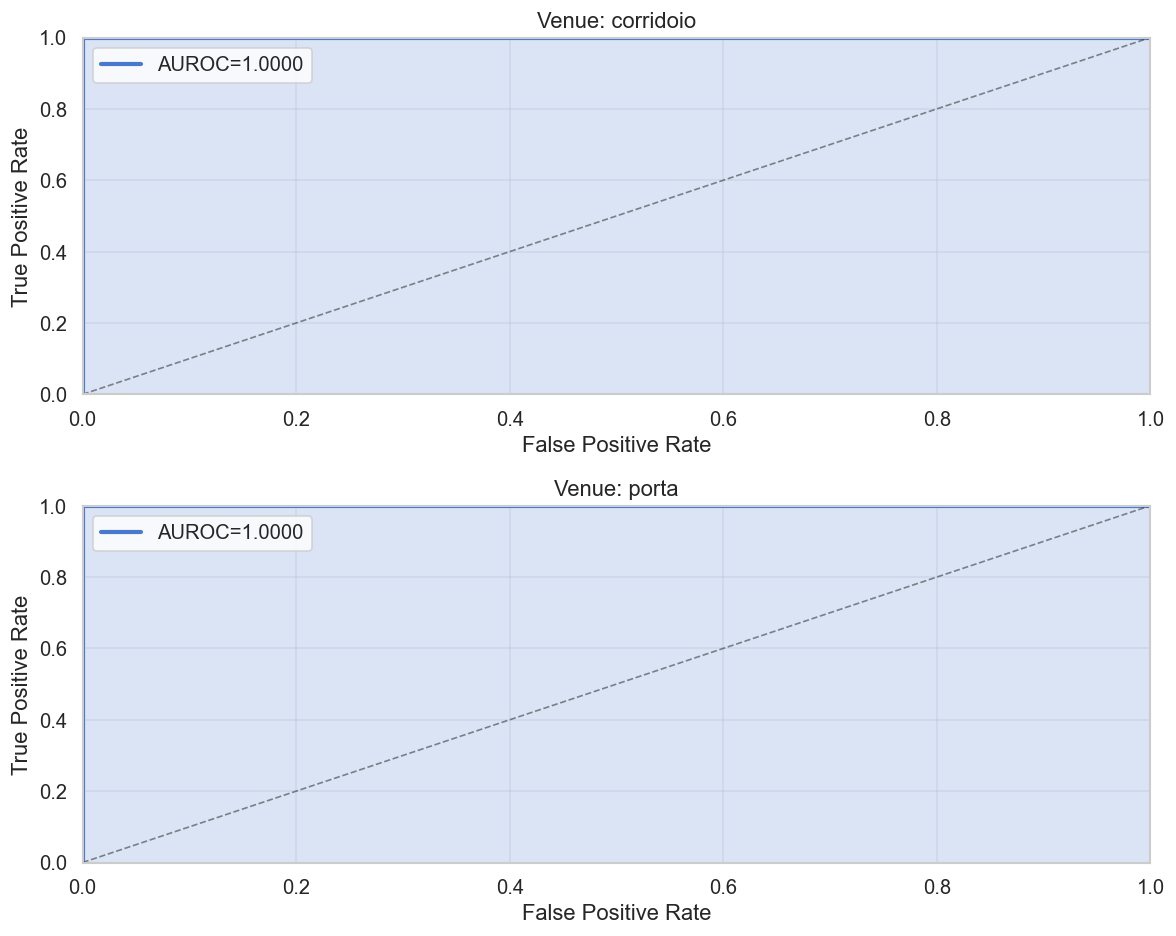

In [35]:
# ── Per-Venue Analysis (if venue_type available) ──────────────────────────────

if 'venue_type' in df.columns and df['venue_type'].nunique() > 1:
    venues = df['venue_type'].unique()
    fig, axes = plt.subplots(len(venues), 1, figsize=(10, 4*len(venues)))
    if len(venues) == 1:
        axes = [axes]
    
    for i, venue in enumerate(venues):
        venue_df = df[df['venue_type'] == venue]
        normal_venue = venue_df[venue_df['test_type'] == 'normal']
        obstructed_venue = venue_df[venue_df['test_type'] == 'obstructed']
        
        if len(obstructed_venue) > 0:
            labels_venue = pd.concat([
                pd.Series([0] * len(normal_venue)),
                pd.Series([1] * len(obstructed_venue))
            ], ignore_index=True)
            scores_venue = pd.concat([
                normal_venue['score'],
                obstructed_venue['score']
            ], ignore_index=True)
            
            auroc_venue = roc_auc_score(labels_venue, scores_venue)
            fpr_v, tpr_v, _ = roc_curve(labels_venue, scores_venue)
            
            axes[i].plot(fpr_v, tpr_v, lw=2.5, label=f'AUROC={auroc_venue:.4f}')
            axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
            axes[i].fill_between(fpr_v, tpr_v, alpha=0.2)
            axes[i].set_xlabel('False Positive Rate')
            axes[i].set_ylabel('True Positive Rate')
            axes[i].set_title(f'Venue: {venue}')
            axes[i].legend()
            axes[i].grid(alpha=0.3)
            axes[i].set_xlim([0, 1])
            axes[i].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()

---
## 5. Shadow FPR - Robustness to Synthetic Shadows

In [36]:
# ── Shadow FPR: Robustness to synthetic shadows ───────────────────────────────

if len(shadow_df) > 0:
    shadow_tp = (shadow_df['score'] > shadow_df['threshold']).sum()
    shadow_fp = (shadow_df['score'] <= shadow_df['threshold']).sum()
    shadow_fpr = shadow_fp / (shadow_fp + shadow_tp) if (shadow_fp + shadow_tp) > 0 else np.nan
    
    print(f'Shadow statistics:')
    print(f'  True Positives (correctly flagged): {shadow_tp}')
    print(f'  False Positives (normal incorrectly flagged): {shadow_fp}')
    print(f'  Shadow FPR: {shadow_fpr:.4f}')
    
    # Distribution
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(shadow_df['score'], bins=50, alpha=0.7, color='orange', edgecolor='black')
    ax.axvline(shadow_df['threshold'].iloc[0], color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Frequency')
    ax.set_title('Shadow Score Distribution')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print('No shadow test data available.')

No shadow test data available.


---
## 6. Score per image - ranking

False Positives: 5 / 990
False Positive Rate: 0.0051

Top 10 FPs:
         score  threshold venue_type
1022  3.129020   2.353368      porta
1184  3.033357   2.534469      porta
1278  2.861841   2.680900      porta
1498  2.496327   2.319587      porta
1340  2.495047   2.326201      porta


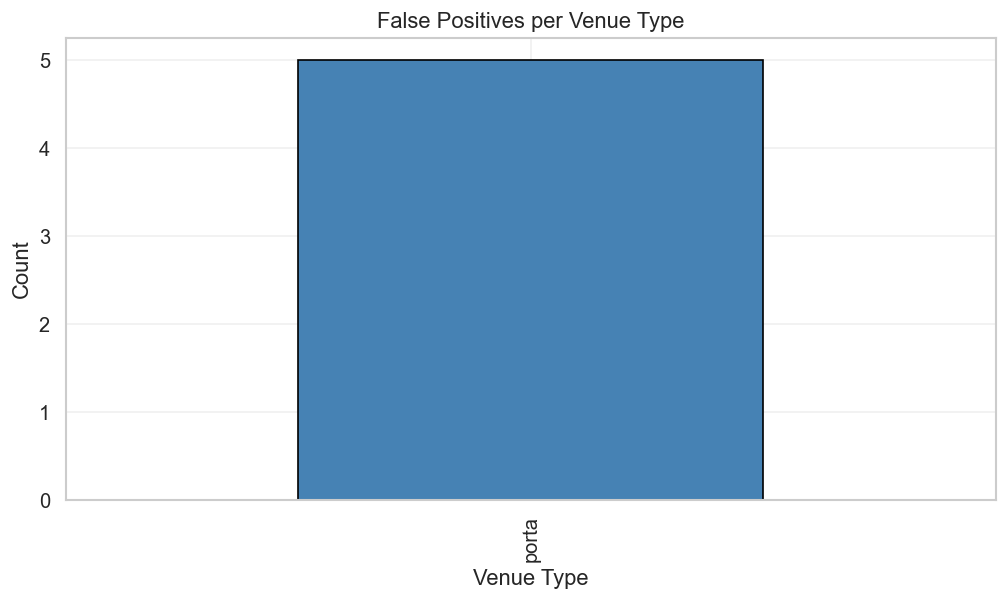

In [37]:
# ── False Positives (normal images misclassified as anomalies) ─────────────────

fp_df = normal_df[normal_df['score'] > normal_df['threshold']].sort_values('score', ascending=False)
print(f'False Positives: {len(fp_df)} / {len(normal_df)}')
print(f'False Positive Rate: {len(fp_df) / len(normal_df):.4f}')
print('\nTop 10 FPs:')
print(fp_df[['score', 'threshold', 'venue_type']].head(10).to_string())

# FP distribution by venue
if 'venue_type' in df.columns and len(fp_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    fp_by_venue = fp_df['venue_type'].value_counts()
    if len(fp_by_venue) > 0:
        fp_by_venue.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_xlabel('Venue Type')
        ax.set_ylabel('Count')
        ax.set_title('False Positives per Venue Type')
        ax.grid(alpha=0.3)
        plt.show()
    else:
        print('No false positives to plot.')

In [38]:
# ── False Negatives (obstructed images misclassified as normal) ────────────────

fn_df = obstructed_df[obstructed_df['score'] <= obstructed_df['threshold']].sort_values('score', ascending=True)
print(f'False Negatives: {len(fn_df)} / {len(obstructed_df)}')
print(f'False Negative Rate: {len(fn_df) / len(obstructed_df):.4f}')
print('\nBottom 10 FNs (hardest to detect):')
print(fn_df[['score', 'threshold', 'venue_type']].head(10).to_string())

# FN distribution by venue
if 'venue_type' in df.columns and len(fn_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    fn_by_venue = fn_df['venue_type'].value_counts()
    if len(fn_by_venue) > 0:
        fn_by_venue.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
        ax.set_xlabel('Venue Type')
        ax.set_ylabel('Count')
        ax.set_title('False Negatives per Venue Type')
        ax.grid(alpha=0.3)
        plt.show()
    else:
        print('No false negatives to plot.')

False Negatives: 0 / 990
False Negative Rate: 0.0000

Bottom 10 FNs (hardest to detect):
Empty DataFrame
Columns: [score, threshold, venue_type]
Index: []


---
## 7. Threshold Analysis - FPR / TPR vs k·σ

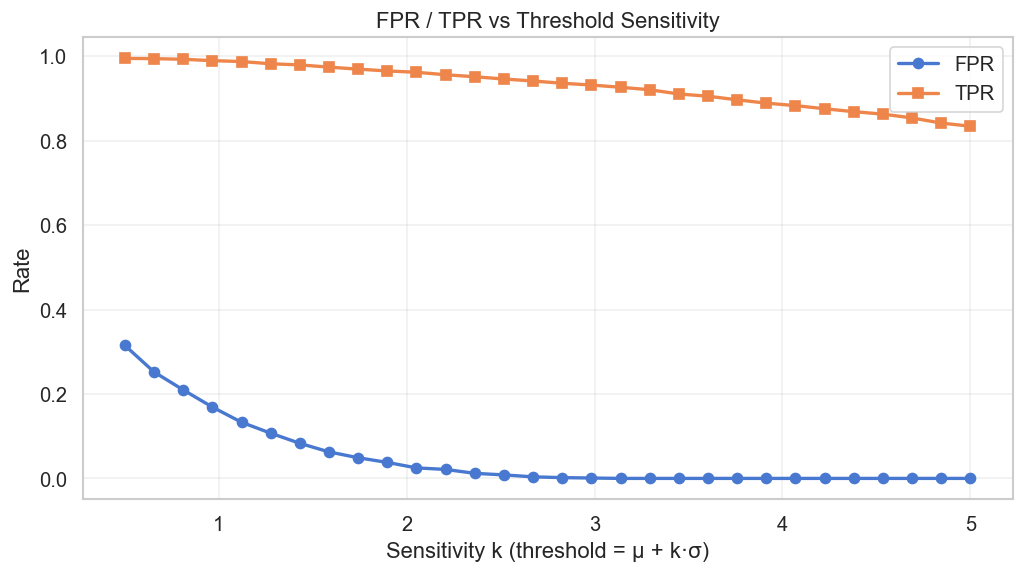

In [39]:
# ── Threshold Sensitivity: FPR / TPR vs k·σ ──────────────────────────────────

if 'threshold' in df.columns:
    # Try to infer k from threshold if available
    # threshold = μ + k·σ, so k = (threshold - μ) / σ
    
    k_values = np.linspace(0.5, 5.0, 30)
    fprs = []
    tprs = []
    
    for k in k_values:
        # Estimate threshold from normal data
        threshold_k = normal_df['score'].mean() + k * normal_df['score'].std()
        
        # Apply to all data
        predicted = (df['score'] > threshold_k).astype(int)
        all_labels_full = df['is_anomaly'].astype(int)
        
        # FPR: false positives / (false positives + true negatives)
        tn = ((all_labels_full == 0) & (predicted == 0)).sum()
        fp = ((all_labels_full == 0) & (predicted == 1)).sum()
        fpr_k = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        # TPR: true positives / (true positives + false negatives)
        tp = ((all_labels_full == 1) & (predicted == 1)).sum()
        fn = ((all_labels_full == 1) & (predicted == 0)).sum()
        tpr_k = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        fprs.append(fpr_k)
        tprs.append(tpr_k)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(k_values, fprs, marker='o', label='FPR', linewidth=2, markersize=6)
    ax.plot(k_values, tprs, marker='s', label='TPR', linewidth=2, markersize=6)
    ax.set_xlabel('Sensitivity k (threshold = μ + k·σ)')
    ax.set_ylabel('Rate')
    ax.set_title('FPR / TPR vs Threshold Sensitivity')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

---
## 8. Heatmap Visualization (overlay from disk)

In [40]:
# ── Heatmap gallery (load from disk if available) ───────────────────────────────

# This section loads anomaly maps (heatmaps) from disk if they exist
# Expected structure: each row should have a 'heatmap_path' column pointing to a .npy or .png

if 'heatmap_path' in df.columns:
    # Sample a few normal and obstructed
    normal_samples = normal_df.dropna(subset=['heatmap_path']).sample(min(3, len(normal_df)), random_state=42)
    obstr_samples = obstructed_df.dropna(subset=['heatmap_path']).sample(min(3, len(obstructed_df)), random_state=42)
    
    for label, samples in [('Normal', normal_samples), ('Obstructed', obstr_samples)]:
        fig = plt.figure(figsize=(12, 4))
        for idx, (_, row) in enumerate(samples.iterrows()):
            ax = fig.add_subplot(1, 3, idx+1)
            try:
                if row['heatmap_path'].endswith('.npy'):
                    hmap = np.load(row['heatmap_path'])
                    im = ax.imshow(hmap, cmap='hot')
                    plt.colorbar(im, ax=ax)
                else:
                    from PIL import Image
                    img = Image.open(row['heatmap_path'])
                    ax.imshow(img)
                ax.set_title(f"Score: {row['score']:.4f}")
                ax.axis('off')
            except Exception as e:
                ax.text(0.5, 0.5, f'Error loading:\n{str(e)[:30]}', 
                       ha='center', va='center', transform=ax.transAxes)
        fig.suptitle(f'{label} Heatmaps', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('No heatmap_path column in data.')

No heatmap_path column in data.


---
## 9. Pair Comparison: Normal vs Obstructed

In [41]:
# ── Pair comparison: reference vs test images ────────────────────────────────

if 'reference_id' in df.columns and 'test_id' in df.columns:
    print('Sample reference-test pairs:')
    sample_pairs = df.drop_duplicates(subset=['reference_id']).sample(min(5, len(df)), random_state=42)
    print(sample_pairs[['reference_id', 'test_id', 'test_type', 'score', 'is_anomaly']].to_string())
    
    # If file_path is available, display images
    if 'file_path' in df.columns:
        from PIL import Image
        fig = plt.figure(figsize=(14, 4))
        for idx, (_, row) in enumerate(sample_pairs.iterrows()[:3]):
            if pd.notna(row.get('file_path')):
                try:
                    img = Image.open(row['file_path'])
                    ax = fig.add_subplot(1, 3, idx+1)
                    ax.imshow(img)
                    ax.set_title(f"Type: {row['test_type']}\\nScore: {row['score']:.3f}")
                    ax.axis('off')
                except Exception as e:
                    print(f'Could not load {row["file_path"]}: {e}')
        plt.tight_layout()
        plt.show()
else:
    print('No reference/test pair information available.')

Sample reference-test pairs:
                                 reference_id                                  test_id test_type     score  is_anomaly
426   non_ostruite/corridoi/corridoio_238.jpg  non_ostruite/corridoi/corridoio_238.jpg    normal  2.231432           0
662   non_ostruite/corridoi/corridoio_371.jpg  non_ostruite/corridoi/corridoio_371.jpg    normal  2.114034           0
1002         non_ostruite/porte/porta_009.jpg         non_ostruite/porte/porta_009.jpg    normal  2.116484           0
618   non_ostruite/corridoi/corridoio_344.jpg  non_ostruite/corridoi/corridoio_344.jpg    normal  2.245800           0
176   non_ostruite/corridoi/corridoio_097.jpg  non_ostruite/corridoi/corridoio_097.jpg    normal  2.231427           0


TypeError: 'generator' object is not subscriptable

<Figure size 1680x480 with 0 Axes>

---
## 10. Final Numerical Summary

In [ ]:
# ── Final Summary ────────────────────────────────────────────────────────────────

print('╔════════════════════════════════════════════════════════════╗')
print('║         PatchCore Anomaly Detection — Summary              ║')
print('╚════════════════════════════════════════════════════════════╝')
print()

print(f'Dataset size:')
print(f'  Normal images:      {len(normal_df):6d}')
print(f'  Obstructed images:  {len(obstructed_df):6d}')
if len(shadow_df) > 0:
    print(f'  Shadow images:      {len(shadow_df):6d}')
print()

print(f'Performance Metrics (Normal vs Obstructed):')
print(f'  AUROC:              {auroc:.4f}')
print(f'  AP (Avg Precision): {ap:.4f}')
print()

print(f'Classification Errors:')
fp_count = len(normal_df[normal_df['score'] > normal_df['threshold']])
fn_count = len(obstructed_df[obstructed_df['score'] <= obstructed_df['threshold']])
print(f'  False Positives:    {fp_count:6d} ({100*fp_count/len(normal_df):5.2f}%)')
print(f'  False Negatives:    {fn_count:6d} ({100*fn_count/len(obstructed_df):5.2f}%)')
print()

if len(shadow_df) > 0:
    shadow_fp = len(shadow_df[shadow_df['score'] > shadow_df['threshold']])
    print(f'Shadow Robustness:')
    print(f'  Shadow FP Count:    {shadow_fp:6d} ({100*shadow_fp/len(shadow_df):5.2f}%)')
    print()

if 'venue_type' in df.columns:
    print(f'Performance by Venue:')
    for venue in df['venue_type'].unique():
        if venue != 'n/a':
            venue_data = df[df['venue_type'] == venue]
            print(f'  {venue:15s}: {len(venue_data):6d} samples')

print()
print('✓ Analysis complete.')